In [95]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer,MissingIndicator, IterativeImputer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder



# !pip install ydata-profiling
# from ydata_profiling import ProfileReport

#### Part A - Conceptual Foundation

#### Part B - Data Acquisition


In [49]:
# Import datasets
# csv
df_csv = pd.read_csv('transactions_main.csv')
display(df_csv.head())

,customer_id,loan_amount,loan_purpose,transaction_count,spending_ratio,default_flag
0,C00001,9160.701553,Home,143,0.772072,0
1,C00002,40556.429836,Business,208,0.588044,0
2,C00003,54039.038178,Home,247,0.662325,0
3,C00004,18820.998791,Home,453,0.395924,0
4,C00005,14495.124874,Education,121,0.167524,0


In [50]:
# json
df_json = pd.read_json('customer_metadata.json')
display(df_json.head())

,customer_id,age,gender,region,education_level,employment_type,join_date
0,C00001,NaN,Male,East,Secondary,Salaried,2021-01-31
1,C00002,30.0,NaN,West,Primary,Self-Employed,2021-12-30
2,C00003,60.0,Male,East,Graduate,Salaried,2020-05-10
3,C00004,52.0,Female,South,Post-Graduate,Salaried,2021-07-18
4,C00005,70.0,Male,East,Post-Graduate,Self-Employed,2021-02-04


In [51]:
# sql
conn = sqlite3.connect('financial_history.db')

table = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(f'Table Name: {table['name'][0]}')

df_sql = pd.read_sql('SELECT * FROM repayment_records', conn)
display(df_sql.head())

Table Name: repayment_records


,customer_id,annual_income,credit_score,repayment_history
0,C00001,66220.926969,686.739425,0
1,C00002,45743.670179,164.529051,2
2,C00003,88735.232342,697.387262,2
3,C00004,90609.732170,587.777427,4
4,C00005,59077.776173,428.924467,3


In [52]:
# Merge

df = df_csv.merge(df_json, on='customer_id').merge(df_sql, on='customer_id')
df

,customer_id,loan_amount,loan_purpose,transaction_count,spending_ratio,default_flag,age,gender,region,education_level,employment_type,join_date,annual_income,credit_score,repayment_history
0,C00001,9160.701553,Home,143,0.772072,0,NaN,Male,East,Secondary,Salaried,2021-01-31,66220.926969,686.739425,0
1,C00002,40556.429836,Business,208,0.588044,0,30.0,NaN,West,Primary,Self-Employed,2021-12-30,45743.670179,164.529051,2
2,C00003,54039.038178,Home,247,0.662325,0,60.0,Male,East,Graduate,Salaried,2020-05-10,88735.232342,697.387262,2
3,C00004,18820.998791,Home,453,0.395924,0,52.0,Female,South,Post-Graduate,Salaried,2021-07-18,90609.732170,587.777427,4
4,C00005,14495.124874,Education,121,0.167524,0,70.0,Male,East,Post-Graduate,Self-Employed,2021-02-04,59077.776173,428.924467,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,C02496,6731.263574,Business,444,0.330863,0,74.0,Female,West,Primary,Unemployed,2019-08-15,79227.316574,682.413804,2
2496,C02497,41407.355017,Car,80,0.673862,1,67.0,NaN,North,Primary,Salaried,2021-08-26,63138.631982,979.606514,0
2497,C02498,44510.359447,Business,391,0.236262,0,51.0,Male,North,Secondary,Salaried,2021-01-14,55461.026960,606.108035,2
2498,C02499,156731.479266,Business,68,0.483820,0,61.0,Male,East,Secondary,NaN,2018-04-02,60389.475345,585.851512,2


#### Part C - Data Understanding & Cleaning

In [53]:
# Fix the arrangement of columns

df = df[['customer_id','age','gender','region','education_level','employment_type','annual_income','loan_amount','loan_purpose','credit_score','repayment_history','transaction_count','spending_ratio','join_date','default_flag']]
display(df.head())

,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,C00001,NaN,Male,East,Secondary,Salaried,66220.926969,9160.701553,Home,686.739425,0,143,0.772072,2021-01-31,0
1,C00002,30.0,NaN,West,Primary,Self-Employed,45743.670179,40556.429836,Business,164.529051,2,208,0.588044,2021-12-30,0
2,C00003,60.0,Male,East,Graduate,Salaried,88735.232342,54039.038178,Home,697.387262,2,247,0.662325,2020-05-10,0
3,C00004,52.0,Female,South,Post-Graduate,Salaried,90609.732170,18820.998791,Home,587.777427,4,453,0.395924,2021-07-18,0
4,C00005,70.0,Male,East,Post-Graduate,Self-Employed,59077.776173,14495.124874,Education,428.924467,3,121,0.167524,2021-02-04,0


In [54]:
# info
print('Info: ')
print({df.info()})

Info: 
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        2500 non-null   str    
 1   age                2200 non-null   float64
 2   gender             2200 non-null   str    
 3   region             2500 non-null   str    
 4   education_level    2500 non-null   str    
 5   employment_type    2200 non-null   str    
 6   annual_income      2215 non-null   float64
 7   loan_amount        2500 non-null   float64
 8   loan_purpose       2500 non-null   str    
 9   credit_score       2212 non-null   float64
 10  repayment_history  2500 non-null   int64  
 11  transaction_count  2500 non-null   int64  
 12  spending_ratio     2500 non-null   float64
 13  join_date          2500 non-null   str    
 14  default_flag       2500 non-null   int64  
dtypes: float64(5), int64(3), str(7)
memory usage: 293.1 KB
{None}


In [55]:
print('Describe: ')
print(df.describe().round(2).to_string())

Describe: 
           age  annual_income  loan_amount  credit_score  repayment_history  transaction_count  spending_ratio  default_flag
count  2200.00        2215.00      2500.00       2212.00            2500.00            2500.00         2500.00        2500.0
mean     47.42       74053.32     30536.45        650.07               1.55             250.20            0.45           0.2
std      15.46       71715.35     28750.62        121.88               1.22             143.12            0.20           0.4
min      21.00      -18535.36       884.22        110.30               0.00              10.00            0.10           0.0
25%      34.00       43258.27     12815.47        593.31               1.00             123.75            0.27           0.0
50%      47.00       61397.80     21754.09        652.63               1.00             248.00            0.45           0.0
75%      61.00       79361.85     38471.67        712.12               2.00             377.00            0.62    

In [56]:
print('Null Values Count:')
print(df.isnull().sum())

Null Values Count:
customer_id            0
age                  300
gender               300
region                 0
education_level        0
employment_type      300
annual_income        285
loan_amount            0
loan_purpose           0
credit_score         288
repayment_history      0
transaction_count      0
spending_ratio         0
join_date              0
default_flag           0
dtype: int64


In [57]:
# ProfileReport

# profile = ProfileReport(df, title='Customer Credit Risk Dataset EDA Report', explorative=True)
#
# profile.to_file('titanic_eda.html')

In [58]:
# SimpleImputer

df_simp = df.copy()

mean_imp = SimpleImputer(strategy='mean')
median_imp = SimpleImputer(strategy='median')
freq_imp = SimpleImputer(strategy='most_frequent')

df_simp['age'] = mean_imp.fit_transform(df_simp[['age']])

df_simp[['gender', 'employment_type']] = freq_imp.fit_transform(df_simp[['gender', 'employment_type']])

df_simp[['annual_income', 'credit_score']] = median_imp.fit_transform(df_simp[['annual_income', 'credit_score']])

print('After applying SimpleImputer: ')
display(df_simp[['age','gender','employment_type','annual_income','credit_score']].head(10))

After applying SimpleImputer: 


,age,gender,employment_type,annual_income,credit_score
0,47.420909,Male,Salaried,66220.926969,686.739425
1,30.000000,Male,Self-Employed,45743.670179,164.529051
2,60.000000,Male,Salaried,88735.232342,697.387262
3,52.000000,Female,Salaried,90609.732170,587.777427
4,70.000000,Male,Self-Employed,59077.776173,428.924467
5,53.000000,Male,Self-Employed,45392.624258,551.321287
6,22.000000,Other,Self-Employed,19600.591657,652.628029
7,53.000000,Male,Salaried,38285.089234,711.786883
8,53.000000,Male,Salaried,5822.748462,787.411815
9,61.000000,Male,Salaried,37233.936998,677.294370


In [59]:
# Missing Indicator + Random Sample Imputation

df_rand = df.copy()

def random_sample_imp(df,col,random_state=9009):
    np.random.seed(random_state)

    null_count = df[col].isnull().sum()

    if null_count > 0:
        random_value = df[col].dropna().sample(
            n=null_count,
            replace=True,
            random_state=random_state
        ).values

        df_ = df.copy()
        df_.loc[df_[col].isnull(),col] = random_value

        return df_
    return df

miss_ind = MissingIndicator(features='missing-only')
miss_ind_array = miss_ind.fit_transform(df_rand)
miss_ind_col = [df_rand.columns[col] + '_missing' for col in miss_ind.features_]
df_miss_ind = pd.DataFrame(miss_ind_array.astype(int), columns=miss_ind_col)

print('Missing Values: ')
display(df_miss_ind.head())

Missing Values: 


,age_missing,gender_missing,employment_type_missing,annual_income_missing,credit_score_missing
0,1,0,0,0,0
1,0,1,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0


In [60]:
for col in df_rand.columns:
    df_rand = random_sample_imp(df_rand,col)

print('After applying Random Sample Imputation: ')
display(df_rand.head(10))

After applying Random Sample Imputation: 


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,C00001,36.0,Male,East,Secondary,Salaried,66220.926969,9160.701553,Home,686.739425,0,143,0.772072,2021-01-31,0
1,C00002,30.0,Male,West,Primary,Self-Employed,45743.670179,40556.429836,Business,164.529051,2,208,0.588044,2021-12-30,0
2,C00003,60.0,Male,East,Graduate,Salaried,88735.232342,54039.038178,Home,697.387262,2,247,0.662325,2020-05-10,0
3,C00004,52.0,Female,South,Post-Graduate,Salaried,90609.732170,18820.998791,Home,587.777427,4,453,0.395924,2021-07-18,0
4,C00005,70.0,Male,East,Post-Graduate,Self-Employed,59077.776173,14495.124874,Education,428.924467,3,121,0.167524,2021-02-04,0
5,C00006,53.0,Female,South,Primary,Self-Employed,45392.624258,12166.880186,Car,551.321287,2,472,0.218217,2020-12-31,0
6,C00007,22.0,Other,North,Post-Graduate,Self-Employed,19600.591657,89982.751671,Education,669.255186,0,61,0.787858,2022-09-21,0
7,C00008,53.0,Male,West,Secondary,Salaried,38285.089234,15339.451662,Home,711.786883,2,146,0.445229,2020-11-10,0
8,C00009,53.0,Male,East,Graduate,Unemployed,5822.748462,37147.488790,Home,787.411815,3,264,0.108414,2022-06-27,0
9,C00010,61.0,Male,East,Graduate,Salaried,37233.936998,18926.929792,Business,677.294370,1,124,0.768757,2018-05-02,0


In [92]:
# KNN

df_knn = df.copy()

df_knn_dropped = df_knn.drop(['customer_id','default_flag','join_date'], axis=1)
df_knn.drop(['customer_id','default_flag','join_date'], axis=1, inplace=True)


cols = ['gender','region','employment_type','loan_purpose','education_level']
oe = OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=np.nan)
df_knn[cols] = oe.fit_transform(df_knn[cols])

knn = KNNImputer(n_neighbors = 10, weights = 'distance')
df_knn = pd.DataFrame(knn.fit_transform(df_knn), columns=df_knn.columns)

df_knn[cols] = df_knn[cols].round().astype(int)
df_knn[cols] = oe.inverse_transform(df_knn[cols])

print('After applying KNNImputer: ')
display(df_knn.head(10))

After applying KNNImputer: 


,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio
0,47.041642,Male,East,Secondary,Salaried,66220.926969,9160.701553,Home,686.739425,0.0,143.0,0.772072
1,30.000000,Male,West,Primary,Self-Employed,45743.670179,40556.429836,Business,164.529051,2.0,208.0,0.588044
2,60.000000,Male,East,Graduate,Salaried,88735.232342,54039.038178,Home,697.387262,2.0,247.0,0.662325
3,52.000000,Female,South,Post-Graduate,Salaried,90609.732170,18820.998791,Home,587.777427,4.0,453.0,0.395924
4,70.000000,Male,East,Post-Graduate,Self-Employed,59077.776173,14495.124874,Education,428.924467,3.0,121.0,0.167524
5,53.000000,Male,South,Primary,Self-Employed,45392.624258,12166.880186,Car,551.321287,2.0,472.0,0.218217
6,22.000000,Other,North,Post-Graduate,Self-Employed,19600.591657,89982.751671,Education,618.804856,0.0,61.0,0.787858
7,53.000000,Male,West,Secondary,Salaried,38285.089234,15339.451662,Home,711.786883,2.0,146.0,0.445229
8,53.000000,Male,East,Graduate,Salaried,5822.748462,37147.488790,Home,787.411815,3.0,264.0,0.108414
9,61.000000,Male,East,Graduate,Salaried,37233.936998,18926.929792,Business,677.294370,1.0,124.0,0.768757


In [94]:
# MICE

df_mice = df.copy()

df_mice_dropped = df_mice.drop(['customer_id','default_flag','join_date'], axis=1)
df_mice.drop(['customer_id','default_flag','join_date'], axis=1, inplace=True)

cols = ['gender','region','employment_type','loan_purpose','education_level']
oe = OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=np.nan)
df_mice[cols] = oe.fit_transform(df_mice[cols])

mice = IterativeImputer(max_iter=400, random_state=9009)
df_mice = pd.DataFrame(mice.fit_transform(df_mice), columns=df_mice.columns)

df_mice[cols] = df_mice[cols].round().astype(int)
df_mice[cols] = oe.inverse_transform(df_mice[cols])

print('After applying MICE Algorithm: ')
display(df_mice.head(10))

After applying MICE Algorithm: 


,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio
0,47.096177,Male,East,Secondary,Salaried,66220.926969,9160.701553,Home,686.739425,0.0,143.0,0.772072
1,30.000000,Male,West,Primary,Self-Employed,45743.670179,40556.429836,Business,164.529051,2.0,208.0,0.588044
2,60.000000,Male,East,Graduate,Salaried,88735.232342,54039.038178,Home,697.387262,2.0,247.0,0.662325
3,52.000000,Female,South,Post-Graduate,Salaried,90609.732170,18820.998791,Home,587.777427,4.0,453.0,0.395924
4,70.000000,Male,East,Post-Graduate,Self-Employed,59077.776173,14495.124874,Education,428.924467,3.0,121.0,0.167524
5,53.000000,Male,South,Primary,Self-Employed,45392.624258,12166.880186,Car,551.321287,2.0,472.0,0.218217
6,22.000000,Other,North,Post-Graduate,Self-Employed,19600.591657,89982.751671,Education,635.857395,0.0,61.0,0.787858
7,53.000000,Male,West,Secondary,Salaried,38285.089234,15339.451662,Home,711.786883,2.0,146.0,0.445229
8,53.000000,Male,East,Graduate,Salaried,5822.748462,37147.488790,Home,787.411815,3.0,264.0,0.108414
9,61.000000,Male,East,Graduate,Salaried,37233.936998,18926.929792,Business,677.294370,1.0,124.0,0.768757


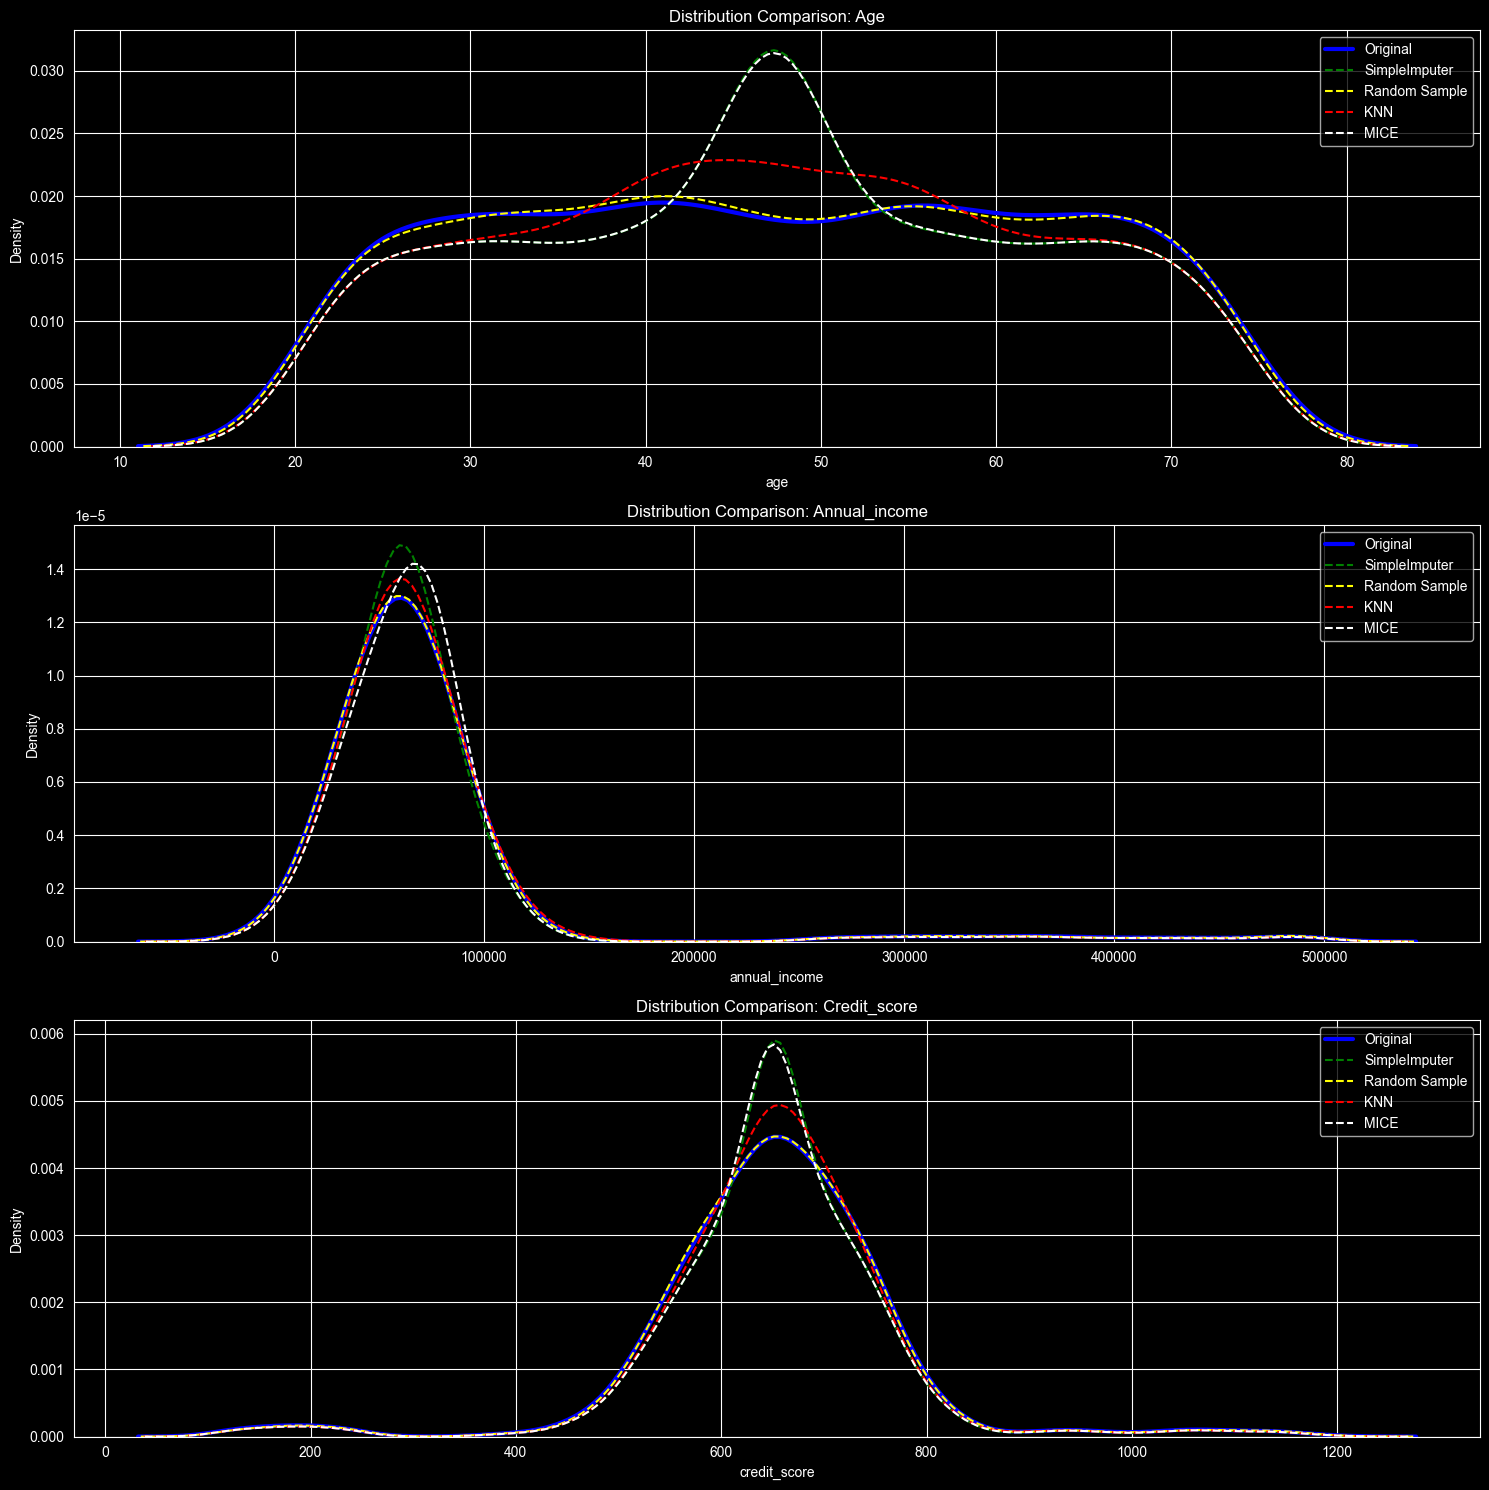

In [105]:
# Compare

figs, axes = plt.subplots(3,1,figsize=(15,15))
axes = axes.flatten()

cols_to_compare = ['age','annual_income','credit_score']

for i, col in enumerate(cols_to_compare):
    sns.kdeplot(df[col].dropna(), label='Original', ax=axes[i], linewidth=3, color='blue')
    sns.kdeplot(df_simp[col], label='SimpleImputer', ax=axes[i], linestyle='--', color='green')
    sns.kdeplot(df_rand[col], label='Random Sample', ax=axes[i], linestyle='--',color='yellow')
    sns.kdeplot(df_knn[col], label='KNN', ax=axes[i], linestyle='--', color='red')
    sns.kdeplot(df_mice[col], label='MICE', ax=axes[i], linestyle='--', color='white')

    axes[i].set_title(f'Distribution Comparison: {col.capitalize()}')
    axes[i].legend()

plt.tight_layout()
plt.show()



#### Part D - Outlier Handling

#### Part E - Feature Engineering

#### Part F - Feature Scaling

#### Part G - Feature Construction & Transformation

#### Part H - Final Deliverable